In [1]:
!pip install kaggle -q



In [2]:
!kaggle datasets download -d ashishjangra27/face-mask-12k-images-dataset
!unzip -q face-mask-12k-images-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/ashishjangra27/face-mask-12k-images-dataset
License(s): CC0-1.0
100% 330M/330M [00:02<00:00, 118MB/s]



In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')


In [7]:
BASE_DIR = 'Face Mask Dataset'

In [8]:
# Class distribution per split
splits = ['Train', 'Validation', 'Test']
classes = ['WithMask', 'WithoutMask']

counts = {}
for split in splits:
    counts[split] = {}
    for cls in classes:
        path = os.path.join(BASE_DIR, split, cls)
        counts[split][cls] = len(os.listdir(path))

df_counts = pd.DataFrame(counts).T
print(df_counts)
print('\nTotal:', df_counts.sum())

            WithMask  WithoutMask
Train           5000         5000
Validation       400          400
Test             483          509

Total: WithMask       5883
WithoutMask    5909
dtype: int64


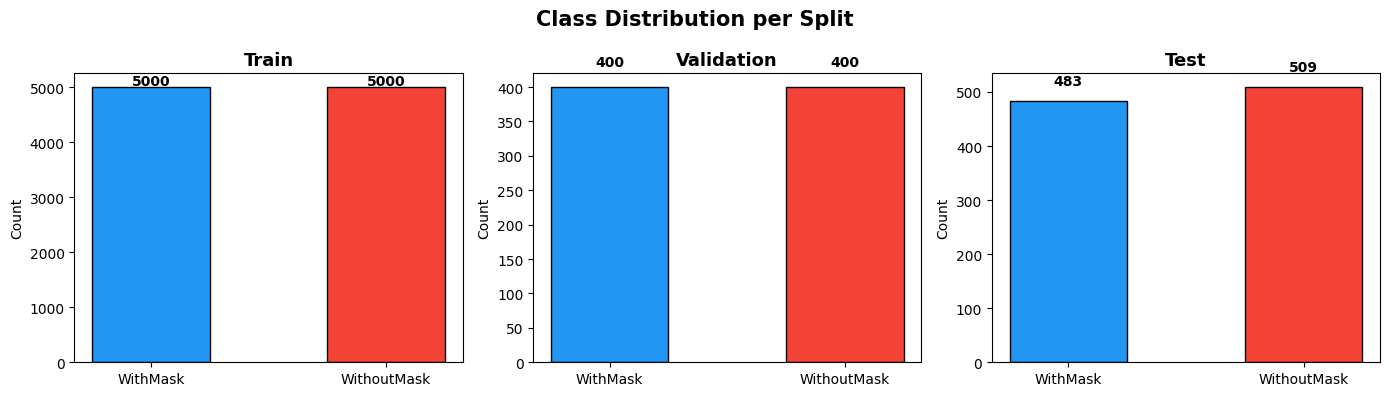

In [9]:
# Bar chart of class distribution
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['#2196F3', '#F44336']

for ax, split in zip(axes, splits):
    vals = [counts[split]['WithMask'], counts[split]['WithoutMask']]
    bars = ax.bar(classes, vals, color=colors, edgecolor='black', width=0.5)
    ax.set_title(split, fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, str(v),
                ha='center', fontweight='bold')

plt.suptitle('Class Distribution per Split', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

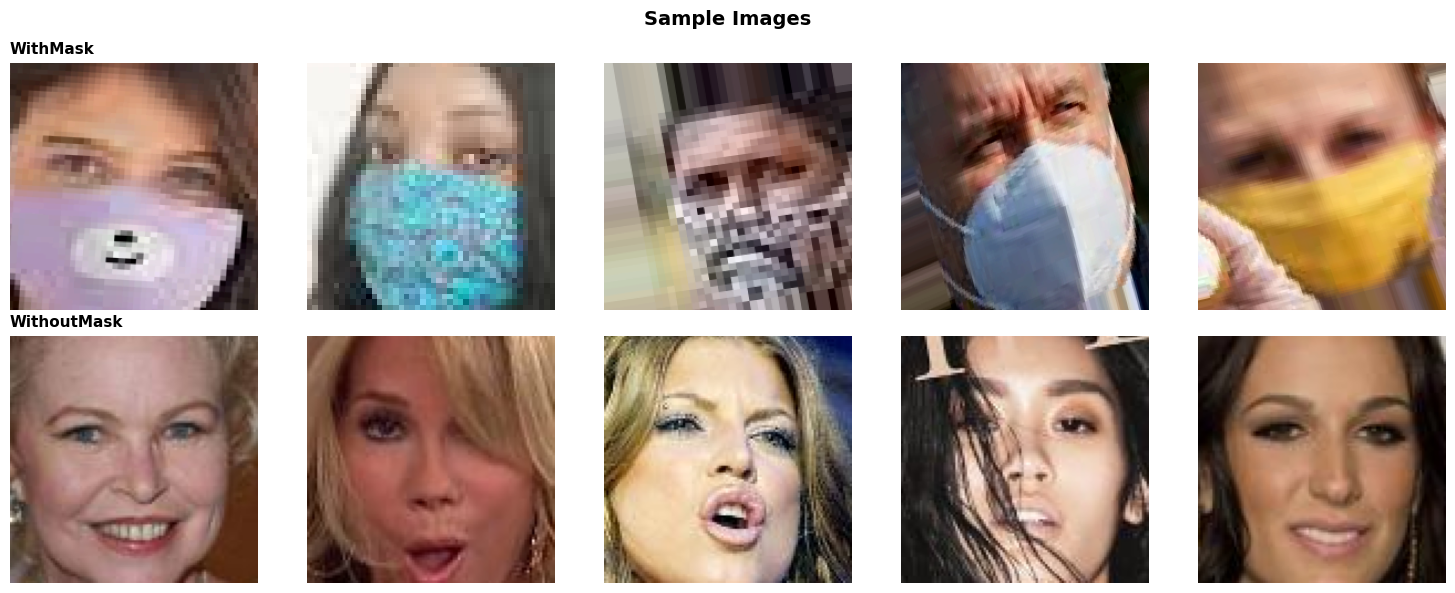

In [10]:
# Sample images from each class
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for row, cls in enumerate(classes):
    folder = os.path.join(BASE_DIR, 'Train', cls)
    imgs = os.listdir(folder)[:5]
    for col, img_name in enumerate(imgs):
        img = mpimg.imread(os.path.join(folder, img_name))
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(cls, fontsize=11, fontweight='bold', loc='left')

plt.suptitle('Sample Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 10

TRAIN_DIR = os.path.join(BASE_DIR, 'Train')
VAL_DIR   = os.path.join(BASE_DIR, 'Validation')
TEST_DIR  = os.path.join(BASE_DIR, 'Test')

# Training: augmentation + normalization
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

# Val & Test: only normalization
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='binary'
)

val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='binary'
)

test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)

print('Class indices:', train_gen.class_indices)

Found 10000 images belonging to 2 classes.
Found 800 images belonging to 2 classes.
Found 992 images belonging to 2 classes.
Class indices: {'WithMask': 0, 'WithoutMask': 1}


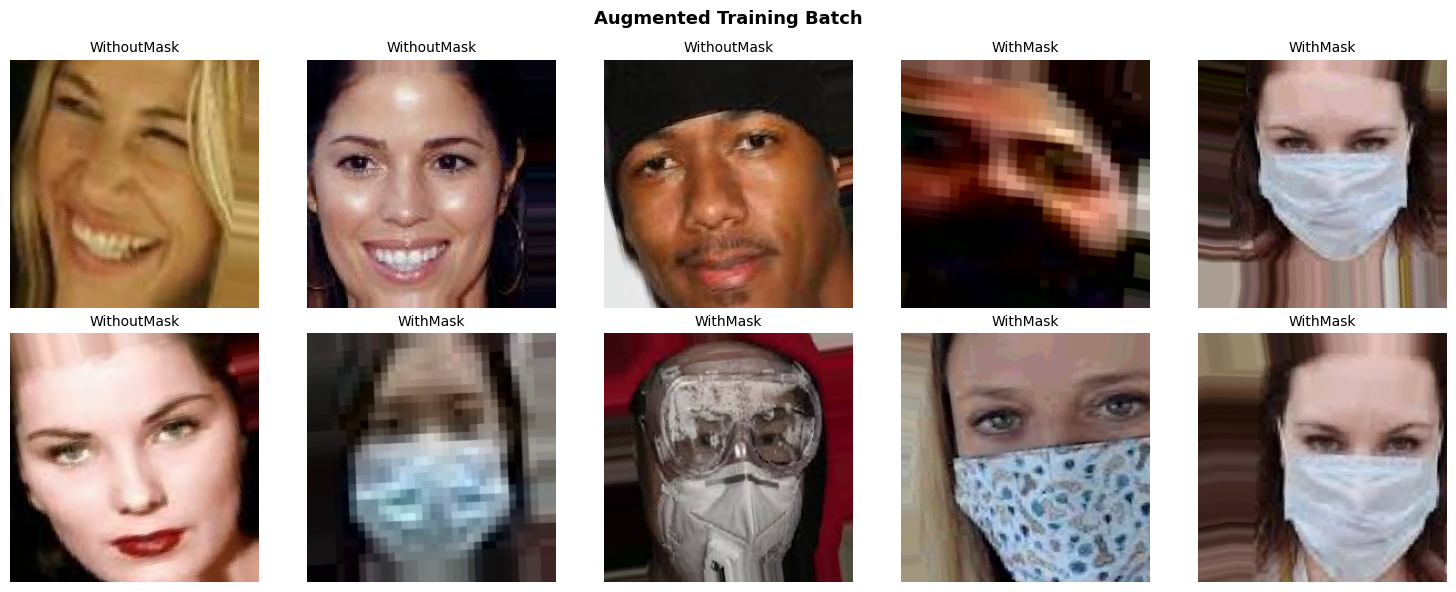

In [14]:
# Visualize a batch of augmented images
batch_imgs, batch_labels = next(train_gen)
label_names = {v: k for k, v in train_gen.class_indices.items()}

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(batch_imgs[i])
    ax.set_title(label_names[int(batch_labels[i])], fontsize=10)
    ax.axis('off')

plt.suptitle('Augmented Training Batch', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
effnet_base = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
effnet_base.trainable = False  # freeze all layers

effnet_model = models.Sequential([
    effnet_base,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

effnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

effnet_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,218,788 (16.09 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [17]:
effnet_callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, verbose=1)
]

effnet_history = effnet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=effnet_callbacks
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 199s 527ms/step - accuracy: 0.5442 - loss: 0.7770 - val_accuracy: 0.5200 - val_loss: 0.6901 - learning_rate: 0.0010
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 123s 393ms/step - accuracy: 0.5746 - loss: 0.6947 - val_accuracy: 0.5175 - val_loss: 0.6816 - learning_rate: 0.0010
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 123s 391ms/step - accuracy: 0.5841 - loss: 0.6762 - val_accuracy: 0.5450 - val_loss: 0.6767 - learning_rate: 0.0010
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 123s 391ms/step - accuracy: 0.5905 - loss: 0.6605 - val_accuracy: 0.5250 - val_loss: 0.6755 - learning_rate: 0.0010
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 122s 389ms/step - accuracy: 0.6032 - loss: 0.6555 - val_accuracy: 0.5275 - val_loss: 0.6812 - learning_rate: 0.0010
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.6006 - loss: 0.6587
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
313/313 ━━━━━━━━━━━━━━━━━━━━ 124s 396ms/step - accuracy:

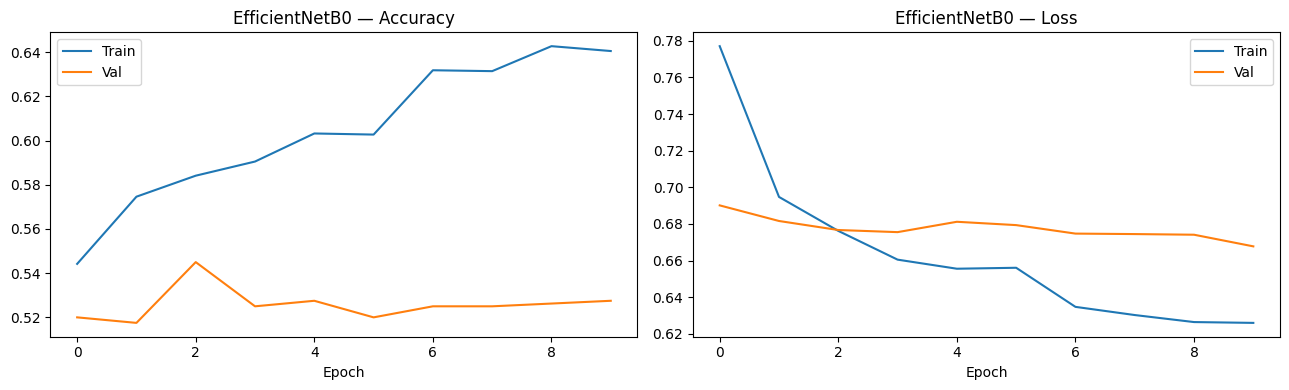

In [18]:
# Training curves — EfficientNet
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(effnet_history.history['accuracy'],    label='Train')
axes[0].plot(effnet_history.history['val_accuracy'], label='Val')
axes[0].set_title('EfficientNetB0 — Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(effnet_history.history['loss'],    label='Train')
axes[1].plot(effnet_history.history['val_loss'], label='Val')
axes[1].set_title('EfficientNetB0 — Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.5504 - loss: 0.6549
EfficientNetB0 — Test Loss: 0.6549 | Test Accuracy: 0.5504
31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step

Classification Report:
              precision    recall  f1-score   support

    WithMask       1.00      0.08      0.14       483
 WithoutMask       0.53      1.00      0.70       509

    accuracy                           0.55       992
   macro avg       0.77      0.54      0.42       992
weighted avg       0.76      0.55      0.43       992



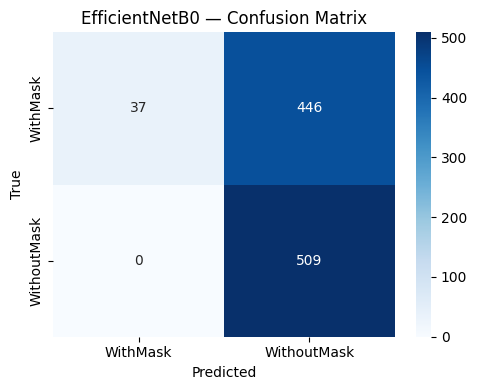

In [19]:
# Evaluate EfficientNet on test set
test_gen.reset()
effnet_loss, effnet_acc = effnet_model.evaluate(test_gen)
print(f'EfficientNetB0 — Test Loss: {effnet_loss:.4f} | Test Accuracy: {effnet_acc:.4f}')

test_gen.reset()
effnet_preds = (effnet_model.predict(test_gen) > 0.5).astype(int).flatten()
true_labels  = test_gen.classes

print('\nClassification Report:')
print(classification_report(true_labels, effnet_preds,
                             target_names=list(test_gen.class_indices.keys())))

cm = confusion_matrix(true_labels, effnet_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_gen.class_indices.keys(),
            yticklabels=test_gen.class_indices.keys())
plt.title('EfficientNetB0 — Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [28]:
effnet_model.save('efficientnetb0_mask.h5')
effnet_model.save('efficientnetb0_mask.keras')


In [20]:
mobilenet_base = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
mobilenet_base.trainable = False  # freeze all layers

mobilenet_model = models.Sequential([
    mobilenet_base,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
], name='MobileNetV2_Frozen')

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_Frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,201 (9.26 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [21]:
mobilenet_callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, verbose=1)
]

mobilenet_history = mobilenet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=mobilenet_callbacks
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 149s 428ms/step - accuracy: 0.9791 - loss: 0.0621 - val_accuracy: 0.9962 - val_loss: 0.0163 - learning_rate: 0.0010
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 120s 384ms/step - accuracy: 0.9905 - loss: 0.0296 - val_accuracy: 0.9937 - val_loss: 0.0219 - learning_rate: 0.0010
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.9895 - loss: 0.0326
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
313/313 ━━━━━━━━━━━━━━━━━━━━ 128s 408ms/step - accuracy: 0.9886 - loss: 0.0334 - val_accuracy: 0.9937 - val_loss: 0.0168 - learning_rate: 0.0010
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 130s 414ms/step - accuracy: 0.9923 - loss: 0.0234 - val_accuracy: 0.9937 - val_loss: 0.0149 - learning_rate: 5.0000e-04
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 132s 421ms/step - accuracy: 0.9946 - loss: 0.0189 - val_accuracy: 0.9937 - val_loss: 0.0098 - learning_rate: 5.0000e-04
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 133s 424ms/step - a

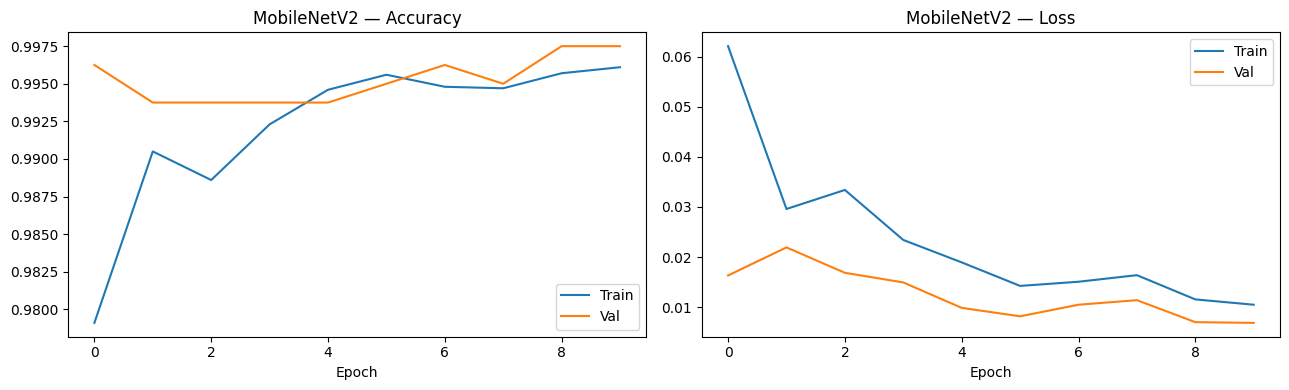

In [22]:
# Training curves — MobileNetV2
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(mobilenet_history.history['accuracy'],    label='Train')
axes[0].plot(mobilenet_history.history['val_accuracy'], label='Val')
axes[0].set_title('MobileNetV2 — Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(mobilenet_history.history['loss'],    label='Train')
axes[1].plot(mobilenet_history.history['val_loss'], label='Val')
axes[1].set_title('MobileNetV2 — Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.9980 - loss: 0.0080
MobileNetV2 — Test Loss: 0.0080 | Test Accuracy: 0.9980
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step

Classification Report:
              precision    recall  f1-score   support

    WithMask       1.00      1.00      1.00       483
 WithoutMask       1.00      1.00      1.00       509

    accuracy                           1.00       992
   macro avg       1.00      1.00      1.00       992
weighted avg       1.00      1.00      1.00       992



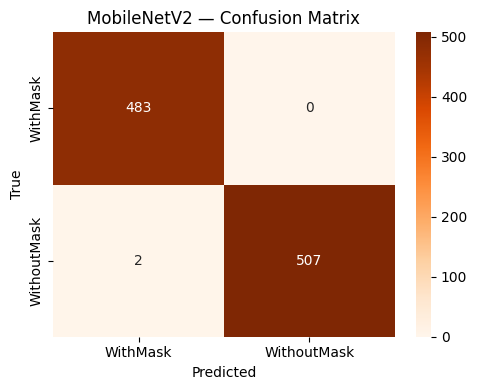

In [23]:
# Evaluate MobileNetV2 on test set
test_gen.reset()
mob_loss, mob_acc = mobilenet_model.evaluate(test_gen)
print(f'MobileNetV2 — Test Loss: {mob_loss:.4f} | Test Accuracy: {mob_acc:.4f}')

test_gen.reset()
mob_preds  = (mobilenet_model.predict(test_gen) > 0.5).astype(int).flatten()
true_labels = test_gen.classes

print('\nClassification Report:')
print(classification_report(true_labels, mob_preds,
                             target_names=list(test_gen.class_indices.keys())))

cm = confusion_matrix(true_labels, mob_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=test_gen.class_indices.keys(),
            yticklabels=test_gen.class_indices.keys())
plt.title('MobileNetV2 — Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [24]:
mobilenet_model.save('mobilenetv2_mask.h5')
print('Models saved.')

Models saved.


In [27]:
mobilenet_model.save('mobilenetv2_mask.keras')